# Analisis Data Kependudukan Jawa Barat Berdasarkan Jenis Kelamin per Desa/Kelurahan (2019-2020)

**Sumber Data:** Open Data Jabar — Dinas Kependudukan dan Pencatatan Sipil Jawa Barat  
**Dataset:** Jumlah Penduduk Berdasarkan Jenis Kelamin per Desa/Kelurahan  
**Periode:** Tahun 2019 dan 2020  

---

## 1. Menentukan Pertanyaan Bisnis

Berdasarkan dataset yang tersedia, berikut adalah pertanyaan bisnis yang memenuhi kriteria **SMART (Specific, Measurable, Action-Oriented, Relevant, Time-Bound)**:

### Pertanyaan 1
> **Kabupaten/kota mana saja yang mengalami pertumbuhan jumlah penduduk tertinggi dan terendah di Provinsi Jawa Barat dari tahun 2019 ke tahun 2020, dan berapa persentase pertumbuhannya?**

- **Specific:** Fokus pada pertumbuhan penduduk di level kabupaten/kota, bukan provinsi secara keseluruhan.
- **Measurable:** Dapat dihitung sebagai persentase perubahan (%) penduduk antara 2019 dan 2020.
- **Action-Oriented:** Pemerintah dapat memprioritaskan alokasi anggaran pelayanan publik (fasilitas kesehatan, pendidikan) di daerah dengan pertumbuhan penduduk tertinggi.
- **Relevant:** Pertumbuhan penduduk merupakan indikator kritis bagi perencanaan tata kota dan alokasi sumber daya.
- **Time-bound:** Dibatasi pada periode 2019–2020.

### Pertanyaan 2
> **Bagaimana distribusi rasio jenis kelamin (sex ratio) penduduk di setiap kabupaten/kota Jawa Barat pada tahun 2020, dan kabupaten/kota mana yang memiliki ketidakseimbangan gender terbesar?**

- **Specific:** Fokus pada rasio jenis kelamin (jumlah laki-laki per 100 perempuan) di level kabupaten/kota.
- **Measurable:** Sex ratio dihitung sebagai (Laki-laki / Perempuan) × 100.
- **Action-Oriented:** Dinas terkait dapat merancang program pemberdayaan atau kebijakan yang lebih inklusif gender di daerah dengan ketidakseimbangan tinggi.
- **Relevant:** Keseimbangan gender penting untuk perencanaan program sosial, ketenagakerjaan, dan kesehatan.
- **Time-bound:** Data tahun 2020.

## 2. Data Wrangling

### 2.1 Gathering Data

Pada tahap ini kita memuat dataset dari file CSV yang bersumber dari Open Data Jawa Barat.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

# Muat dataset
df = pd.read_csv('data/penduduk_jabar.csv')

print('Dataset berhasil dimuat!')
print(f'Jumlah baris: {df.shape[0]:,}')
print(f'Jumlah kolom: {df.shape[1]}')
df.head()

Dataset berhasil dimuat!
Jumlah baris: 23,828
Jumlah kolom: 18


,id,kode_provinsi,nama_provinsi,bps_kode_kabupaten_kota,bps_nama_kabupaten_kota,bps_kode_kecamatan,bps_nama_kecamatan,bps_kode_desa_kelurahan,bps_nama_desa_kelurahan,kemendagri_kode_kecamatan,kemendagri_nama_kecamatan,kemendagri_kode_desa_kelurahan,kemendagri_nama_desa_kelurahan,status_pemerintahan,jenis_kelamin,jumlah_penduduk,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201010,NANGGUNG,3201010001,MALASARI,32.01.21,NANGGUNG,32.01.21.2001,MALASARI,DESA,LAKI-LAKI,3742,JIWA,2019
1,2,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201010,NANGGUNG,3201010001,MALASARI,32.01.21,NANGGUNG,32.01.21.2001,MALASARI,DESA,PEREMPUAN,3416,JIWA,2019
2,3,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201010,NANGGUNG,3201010002,BANTAR KARET,32.01.21,NANGGUNG,32.01.21.2004,BANTARKARET,DESA,LAKI-LAKI,4788,JIWA,2019
3,4,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201010,NANGGUNG,3201010002,BANTAR KARET,32.01.21,NANGGUNG,32.01.21.2004,BANTARKARET,DESA,PEREMPUAN,4346,JIWA,2019
4,5,32,JAWA BARAT,3201,KABUPATEN BOGOR,3201010,NANGGUNG,3201010003,CISARUA,32.01.21,NANGGUNG,32.01.21.2003,CISARUA,DESA,LAKI-LAKI,3444,JIWA,2019


### 2.2 Assessing Data

Pada tahap ini kita akan menilai kualitas data dengan memeriksa berbagai potensi masalah.

In [2]:
# Informasi umum dataset
print('='*60)
print('INFORMASI DATASET')
print('='*60)
df.info()
print()
print('Statistik Deskriptif:')
df.describe()

INFORMASI DATASET
<class 'pandas.DataFrame'>
RangeIndex: 23828 entries, 0 to 23827
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   id                              23828 non-null  int64
 1   kode_provinsi                   23828 non-null  int64
 2   nama_provinsi                   23828 non-null  str  
 3   bps_kode_kabupaten_kota         23828 non-null  int64
 4   bps_nama_kabupaten_kota         23828 non-null  str  
 5   bps_kode_kecamatan              23828 non-null  int64
 6   bps_nama_kecamatan              23828 non-null  str  
 7   bps_kode_desa_kelurahan         23828 non-null  int64
 8   bps_nama_desa_kelurahan         23828 non-null  str  
 9   kemendagri_kode_kecamatan       23828 non-null  str  
 10  kemendagri_nama_kecamatan       23828 non-null  str  
 11  kemendagri_kode_desa_kelurahan  23828 non-null  str  
 12  kemendagri_nama_desa_kelurahan  23828 non-null  str  

,id,kode_provinsi,bps_kode_kabupaten_kota,bps_kode_kecamatan,bps_kode_desa_kelurahan,jumlah_penduduk,tahun
count,23828.000000,23828.0,23828.000000,2.382800e+04,2.382800e+04,23828.000000,23828.00000
mean,11914.500000,32.0,3213.785630,3.213904e+06,3.213904e+09,3899.591111,2019.50000
std,6878.695443,0.0,18.973583,1.895107e+04,1.895107e+07,3915.760332,0.50001
min,1.000000,32.0,3201.000000,3.201010e+06,3.201010e+09,236.000000,2019.00000
25%,5957.750000,32.0,3205.000000,3.205030e+06,3.205030e+09,1946.750000,2019.00000
50%,11914.500000,32.0,3209.000000,3.209041e+06,3.209041e+09,2796.500000,2019.50000
75%,17871.250000,32.0,3213.000000,3.213190e+06,3.213190e+09,4306.000000,2020.00000
max,23828.000000,32.0,3279.000000,3.279040e+06,3.279040e+09,49760.000000,2020.00000


In [3]:
# Pemeriksaan 1: Missing Values
print('='*60)
print('PEMERIKSAAN 1: MISSING VALUES')
print('='*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df)
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

PEMERIKSAAN 1: MISSING VALUES
                                Jumlah Missing  Persentase (%)
id                                           0             0.0
kode_provinsi                                0             0.0
nama_provinsi                                0             0.0
bps_kode_kabupaten_kota                      0             0.0
bps_nama_kabupaten_kota                      0             0.0
bps_kode_kecamatan                           0             0.0
bps_nama_kecamatan                           0             0.0
bps_kode_desa_kelurahan                      0             0.0
bps_nama_desa_kelurahan                      0             0.0
kemendagri_kode_kecamatan                    0             0.0
kemendagri_nama_kecamatan                    0             0.0
kemendagri_kode_desa_kelurahan               0             0.0
kemendagri_nama_desa_kelurahan               0             0.0
status_pemerintahan                          0             0.0
jenis_kelamin            

In [4]:
# Pemeriksaan 2: Data Duplikat
print('='*60)
print('PEMERIKSAAN 2: DUPLIKAT DATA')
print('='*60)
total_duplikat = df.duplicated().sum()
print(f'Jumlah baris duplikat: {total_duplikat}')

# Cek duplikat berdasarkan kombinasi kunci unik
kunci_unik = ['bps_kode_desa_kelurahan', 'jenis_kelamin', 'tahun']
duplikat_kunci = df.duplicated(subset=kunci_unik).sum()
print(f'Duplikat berdasarkan kunci unik (kode_desa, jenis_kelamin, tahun): {duplikat_kunci}')

PEMERIKSAAN 2: DUPLIKAT DATA


Jumlah baris duplikat: 0
Duplikat berdasarkan kunci unik (kode_desa, jenis_kelamin, tahun): 0


In [5]:
# Pemeriksaan 3: Nilai Tidak Valid / Outlier pada jumlah_penduduk
print('='*60)
print('PEMERIKSAAN 3: NILAI OUTLIER (jumlah_penduduk)')
print('='*60)

Q1 = df['jumlah_penduduk'].quantile(0.25)
Q3 = df['jumlah_penduduk'].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = df[(df['jumlah_penduduk'] < batas_bawah) | (df['jumlah_penduduk'] > batas_atas)]
print(f'Batas bawah (IQR): {batas_bawah:.0f}')
print(f'Batas atas (IQR): {batas_atas:.0f}')
print(f'Jumlah outlier: {len(outlier):,}')
print(f'Persentase outlier: {len(outlier)/len(df)*100:.2f}%')
print('\n5 Desa/Kelurahan dengan penduduk terbanyak (outlier atas):')
print(outlier.nlargest(5, 'jumlah_penduduk')[['bps_nama_kabupaten_kota','bps_nama_desa_kelurahan','jenis_kelamin','jumlah_penduduk','tahun']])

PEMERIKSAAN 3: NILAI OUTLIER (jumlah_penduduk)
Batas bawah (IQR): -1592
Batas atas (IQR): 7845
Jumlah outlier: 2,178
Persentase outlier: 9.14%

5 Desa/Kelurahan dengan penduduk terbanyak (outlier atas):
      bps_nama_kabupaten_kota bps_nama_desa_kelurahan jenis_kelamin  \
22094        KABUPATEN BEKASI                WANASARI     LAKI-LAKI   
22095        KABUPATEN BEKASI                WANASARI     PEREMPUAN   
11560             KOTA BEKASI        KALIABANG TENGAH     LAKI-LAKI   
23474             KOTA BEKASI        KALIABANG TENGAH     LAKI-LAKI   
10182        KABUPATEN BEKASI                WANAJAYA     LAKI-LAKI   

       jumlah_penduduk  tahun  
22094            49760   2020  
22095            48892   2020  
11560            47327   2019  
23474            47317   2020  
10182            46378   2019  


In [6]:
# Pemeriksaan 4: Konsistensi Nilai Kategorik
print('='*60)
print('PEMERIKSAAN 4: KONSISTENSI NILAI KATEGORIK')
print('='*60)

print('Nilai unik kolom jenis_kelamin:', df['jenis_kelamin'].unique().tolist())
print('Nilai unik kolom tahun:', sorted(df['tahun'].unique().tolist()))
print('Nilai unik kolom status_pemerintahan:', df['status_pemerintahan'].unique().tolist())
print('Nilai unik kolom satuan:', df['satuan'].unique().tolist())
print(f'Jumlah kabupaten/kota: {df["bps_nama_kabupaten_kota"].nunique()}')
print(f'Jumlah kecamatan: {df["bps_nama_kecamatan"].nunique()}')
print(f'Jumlah desa/kelurahan: {df["bps_nama_desa_kelurahan"].nunique()}')

PEMERIKSAAN 4: KONSISTENSI NILAI KATEGORIK
Nilai unik kolom jenis_kelamin: ['LAKI-LAKI', 'PEREMPUAN']
Nilai unik kolom tahun: [2019, 2020]
Nilai unik kolom status_pemerintahan: ['DESA', 'KELURAHAN']
Nilai unik kolom satuan: ['JIWA']
Jumlah kabupaten/kota: 27
Jumlah kecamatan: 581
Jumlah desa/kelurahan: 3810


**Ringkasan Hasil Assessing Data:**

| Masalah | Temuan | Tindakan |
|---|---|---|
| Missing Values | **Tidak ada** missing values di semua kolom | Tidak perlu penanganan |
| Duplikat | **Tidak ada** duplikat baris maupun kunci unik | Tidak perlu penanganan |
| Outlier | Terdapat **outlier atas** pada `jumlah_penduduk` (desa padat) | Ini nilai valid secara konteks — desa/kelurahan di perkotaan memang padat, **tidak dihapus** |
| Konsistensi | Nilai kategorik **konsisten** dan terstandar | Tidak perlu penanganan |

### 2.3 Cleaning Data

Berdasarkan hasil assessing, data sudah cukup bersih. Kita akan melakukan beberapa langkah penyempurnaan:

In [7]:
# Cleaning: memilih kolom-kolom yang relevan untuk analisis
kolom_relevan = [
    'bps_nama_kabupaten_kota',
    'bps_nama_kecamatan',
    'bps_nama_desa_kelurahan',
    'status_pemerintahan',
    'jenis_kelamin',
    'jumlah_penduduk',
    'tahun'
]

df_clean = df[kolom_relevan].copy()

# Rename kolom agar lebih mudah dibaca
df_clean.columns = ['kabupaten_kota', 'kecamatan', 'desa_kelurahan',
                    'status', 'jenis_kelamin', 'jumlah_penduduk', 'tahun']

# Pastikan tipe data benar
df_clean['tahun'] = df_clean['tahun'].astype(int)
df_clean['jumlah_penduduk'] = df_clean['jumlah_penduduk'].astype(int)

print('Data setelah cleaning:')
print(f'Shape: {df_clean.shape}')
df_clean.head(10)

Data setelah cleaning:
Shape: (23828, 7)


,kabupaten_kota,kecamatan,desa_kelurahan,status,jenis_kelamin,jumlah_penduduk,tahun
0,KABUPATEN BOGOR,NANGGUNG,MALASARI,DESA,LAKI-LAKI,3742,2019
1,KABUPATEN BOGOR,NANGGUNG,MALASARI,DESA,PEREMPUAN,3416,2019
2,KABUPATEN BOGOR,NANGGUNG,BANTAR KARET,DESA,LAKI-LAKI,4788,2019
3,KABUPATEN BOGOR,NANGGUNG,BANTAR KARET,DESA,PEREMPUAN,4346,2019
4,KABUPATEN BOGOR,NANGGUNG,CISARUA,DESA,LAKI-LAKI,3444,2019
5,KABUPATEN BOGOR,NANGGUNG,CISARUA,DESA,PEREMPUAN,3102,2019
6,KABUPATEN BOGOR,NANGGUNG,CURUG BITUNG,DESA,LAKI-LAKI,4609,2019
7,KABUPATEN BOGOR,NANGGUNG,CURUG BITUNG,DESA,PEREMPUAN,4130,2019
8,KABUPATEN BOGOR,NANGGUNG,NANGGUNG,DESA,LAKI-LAKI,3495,2019
9,KABUPATEN BOGOR,NANGGUNG,NANGGUNG,DESA,PEREMPUAN,3186,2019


In [8]:
# Simpan data bersih ke dashboard folder
df_clean.to_csv('dashboard/main_data.csv', index=False)
print('Data bersih berhasil disimpan ke dashboard/main_data.csv')
print(df_clean.dtypes)

Data bersih berhasil disimpan ke dashboard/main_data.csv
kabupaten_kota       str
kecamatan            str
desa_kelurahan       str
status               str
jenis_kelamin        str
jumlah_penduduk    int64
tahun              int64
dtype: object


## 3. Exploratory Data Analysis (EDA)

### 3.1 EDA untuk Pertanyaan 1: Pertumbuhan Penduduk per Kabupaten/Kota (2019–2020)

In [9]:
# Agregasi total penduduk per kabupaten/kota per tahun
pop_kabkota = df_clean.groupby(['kabupaten_kota', 'tahun'])['jumlah_penduduk'].sum().reset_index()
pop_kabkota.columns = ['kabupaten_kota', 'tahun', 'total_penduduk']

# Pivot untuk mempermudah perhitungan pertumbuhan
pop_pivot = pop_kabkota.pivot(index='kabupaten_kota', columns='tahun', values='total_penduduk').reset_index()
pop_pivot.columns = ['kabupaten_kota', 'pop_2019', 'pop_2020']

# Hitung pertumbuhan
pop_pivot['pertumbuhan_absolut'] = pop_pivot['pop_2020'] - pop_pivot['pop_2019']
pop_pivot['pertumbuhan_persen'] = ((pop_pivot['pop_2020'] - pop_pivot['pop_2019']) / pop_pivot['pop_2019'] * 100).round(2)

pop_pivot_sorted = pop_pivot.sort_values('pertumbuhan_persen', ascending=False)
print('Pertumbuhan Penduduk per Kabupaten/Kota (2019-2020):')
print(pop_pivot_sorted.to_string(index=False))

Pertumbuhan Penduduk per Kabupaten/Kota (2019-2020):
         kabupaten_kota  pop_2019  pop_2020  pertumbuhan_absolut  pertumbuhan_persen
           KOTA CIREBON    205711    343003               137292               66.74
             KOTA DEPOK   1202374   1872996               670622               55.77
            KOTA BEKASI   1700211   2464719               764508               44.97
       KABUPATEN BEKASI   2324022   2880280               556258               23.94
        KABUPATEN BOGOR   4201899   5134351               932452               22.19
       KOTA TASIKMALAYA    584592    713290               128698               22.02
             KOTA BOGOR    887769   1064698               176929               19.93
          KOTA SUKABUMI    310724    351459                40735               13.11
           KOTA BANDUNG   2218876   2500967               282091               12.71
KABUPATEN BANDUNG BARAT   1532795   1712348               179553               11.71
      KABUPA

In [10]:
# Statistik pertumbuhan
print('=== STATISTIK PERTUMBUHAN PENDUDUK ===')
print(f'Rata-rata pertumbuhan: {pop_pivot["pertumbuhan_persen"].mean():.2f}%')
print(f'Pertumbuhan tertinggi: {pop_pivot["pertumbuhan_persen"].max():.2f}% ({pop_pivot.loc[pop_pivot["pertumbuhan_persen"].idxmax(), "kabupaten_kota"]})')
print(f'Pertumbuhan terendah: {pop_pivot["pertumbuhan_persen"].min():.2f}% ({pop_pivot.loc[pop_pivot["pertumbuhan_persen"].idxmin(), "kabupaten_kota"]})')
print(f'\nTotal Penduduk Jawa Barat 2019: {pop_pivot["pop_2019"].sum():,}')
print(f'Total Penduduk Jawa Barat 2020: {pop_pivot["pop_2020"].sum():,}')
print(f'Pertumbuhan Total: {((pop_pivot["pop_2020"].sum() - pop_pivot["pop_2019"].sum())/pop_pivot["pop_2019"].sum()*100):.2f}%')

=== STATISTIK PERTUMBUHAN PENDUDUK ===
Rata-rata pertumbuhan: 4.74%
Pertumbuhan tertinggi: 66.74% (KOTA CIREBON)
Pertumbuhan terendah: -29.95% (KABUPATEN KUNINGAN)

Total Penduduk Jawa Barat 2019: 45,776,834
Total Penduduk Jawa Barat 2020: 47,142,623
Pertumbuhan Total: 2.98%


**Insight Pertanyaan 1:**  
Terdapat variasi pertumbuhan yang signifikan antar kabupaten/kota. Beberapa kabupaten mengalami pertumbuhan sangat tinggi, sementara beberapa kota justru mengalami penurunan atau pertumbuhan sangat rendah — kemungkinan karena urbanisasi atau perpindahan penduduk ke daerah sekitarnya.

### 3.2 EDA untuk Pertanyaan 2: Rasio Jenis Kelamin per Kabupaten/Kota

In [11]:
# Hitung sex ratio per kabupaten/kota tahun 2020
pop_2020 = df_clean[df_clean['tahun'] == 2020]

sex_pivot = pop_2020.groupby(['kabupaten_kota', 'jenis_kelamin'])['jumlah_penduduk'].sum().unstack().reset_index()
sex_pivot.columns = ['kabupaten_kota', 'perempuan', 'laki_laki']

sex_pivot['sex_ratio'] = (sex_pivot['laki_laki'] / sex_pivot['perempuan'] * 100).round(2)
sex_pivot['total'] = sex_pivot['laki_laki'] + sex_pivot['perempuan']
sex_pivot['pct_laki'] = (sex_pivot['laki_laki'] / sex_pivot['total'] * 100).round(2)
sex_pivot['pct_perempuan'] = (sex_pivot['perempuan'] / sex_pivot['total'] * 100).round(2)

sex_pivot_sorted = sex_pivot.sort_values('sex_ratio', ascending=False)
print('Sex Ratio per Kabupaten/Kota Jawa Barat (2020):')
print('(Sex ratio = jumlah laki-laki per 100 perempuan)')
print(sex_pivot_sorted[['kabupaten_kota','laki_laki','perempuan','sex_ratio']].to_string(index=False))

Sex Ratio per Kabupaten/Kota Jawa Barat (2020):
(Sex ratio = jumlah laki-laki per 100 perempuan)
         kabupaten_kota  laki_laki  perempuan  sex_ratio
  KABUPATEN PANGANDARAN     213701     214541      99.61
       KABUPATEN SUBANG     789583     794352      99.40
           KOTA CIREBON     170886     172117      99.28
           KOTA BANDUNG    1244761    1256206      99.09
          KOTA SUKABUMI     174920     176539      99.08
       KABUPATEN CIAMIS     619078     625203      99.02
            KOTA BEKASI    1225483    1239236      98.89
            KOTA BANJAR     102108     103374      98.78
             KOTA DEPOK     930456     942540      98.72
            KOTA CIMAHI     277157     280754      98.72
    KABUPATEN INDRAMAYU     928791     942358      98.56
   KABUPATEN MAJALENGKA     652500     662772      98.45
     KABUPATEN SUMEDANG     574684     584770      98.28
     KABUPATEN KARAWANG    1167430    1193589      97.81
       KABUPATEN BEKASI    1423415    1456865   

In [12]:
# Statistik sex ratio
print('=== STATISTIK SEX RATIO 2020 ===')
print(f'Rata-rata sex ratio: {sex_pivot["sex_ratio"].mean():.2f}')
print(f'Sex ratio tertinggi: {sex_pivot["sex_ratio"].max():.2f} ({sex_pivot.loc[sex_pivot["sex_ratio"].idxmax(), "kabupaten_kota"]})')
print(f'Sex ratio terendah: {sex_pivot["sex_ratio"].min():.2f} ({sex_pivot.loc[sex_pivot["sex_ratio"].idxmin(), "kabupaten_kota"]})')

# Sex ratio Jawa Barat keseluruhan
total_lk = pop_2020[pop_2020['jenis_kelamin']=='LAKI-LAKI']['jumlah_penduduk'].sum()
total_pr = pop_2020[pop_2020['jenis_kelamin']=='PEREMPUAN']['jumlah_penduduk'].sum()
print(f'\nSex ratio Jawa Barat 2020: {total_lk/total_pr*100:.2f}')
print(f'Total laki-laki: {total_lk:,}')
print(f'Total perempuan: {total_pr:,}')

=== STATISTIK SEX RATIO 2020 ===
Rata-rata sex ratio: 97.79
Sex ratio tertinggi: 99.61 (KABUPATEN PANGANDARAN)
Sex ratio terendah: 94.72 (KABUPATEN CIANJUR)

Sex ratio Jawa Barat 2020: 102.77
Total laki-laki: 23,893,514
Total perempuan: 23,249,109


**Insight Pertanyaan 2:**  
Secara keseluruhan Jawa Barat memiliki sex ratio mendekati 100 (seimbang), namun terdapat variasi yang menarik antar kabupaten/kota. Beberapa kabupaten industri cenderung memiliki sex ratio lebih tinggi karena banyaknya tenaga kerja laki-laki yang bermigrasi masuk.

### 3.3 Analisis Lanjutan: Clustering Kabupaten/Kota berdasarkan Karakteristik Kependudukan

In [13]:
# Gabungkan data pertumbuhan dan sex ratio
analisis_gabung = pop_pivot.merge(sex_pivot[['kabupaten_kota','sex_ratio','total']], on='kabupaten_kota')

# Binning: Kategorisasi pertumbuhan menggunakan pd.cut
analisis_gabung['kategori_pertumbuhan'] = pd.cut(
    analisis_gabung['pertumbuhan_persen'],
    bins=[-float('inf'), 0, 5, 10, float('inf')],
    labels=['Menurun/Stagnan', 'Rendah (0-5%)', 'Sedang (5-10%)', 'Tinggi (>10%)']
)

# Kategorisasi sex ratio
analisis_gabung['kategori_sex_ratio'] = pd.cut(
    analisis_gabung['sex_ratio'],
    bins=[0, 98, 102, float('inf')],
    labels=['Dominasi Perempuan (<98)', 'Seimbang (98-102)', 'Dominasi Laki-laki (>102)']
)

# Kategorisasi ukuran kabupaten/kota
analisis_gabung['kategori_ukuran'] = pd.cut(
    analisis_gabung['total'],
    bins=[0, 500000, 2000000, float('inf')],
    labels=['Kecil (<500rb)', 'Sedang (500rb-2jt)', 'Besar (>2jt)']
)

print('Clustering berdasarkan Kategori Pertumbuhan:')
print(analisis_gabung.groupby('kategori_pertumbuhan')['kabupaten_kota'].apply(list))
print()
print('Clustering berdasarkan Sex Ratio:')
print(analisis_gabung.groupby('kategori_sex_ratio')['kabupaten_kota'].apply(list))

Clustering berdasarkan Kategori Pertumbuhan:
kategori_pertumbuhan
Menurun/Stagnan    [KABUPATEN CIAMIS, KABUPATEN CIANJUR, KABUPATE...
Sedang (5-10%)                     [KABUPATEN KARAWANG, KOTA CIMAHI]
Tinggi (>10%)      [KABUPATEN BANDUNG, KABUPATEN BANDUNG BARAT, K...
Name: kabupaten_kota, dtype: object

Clustering berdasarkan Sex Ratio:
kategori_sex_ratio
Dominasi Perempuan (<98)    [KABUPATEN BANDUNG, KABUPATEN BANDUNG BARAT, K...
Seimbang (98-102)           [KABUPATEN CIAMIS, KABUPATEN INDRAMAYU, KABUPA...
Name: kabupaten_kota, dtype: object


## 4. Visualization & Explanatory Analysis

### Visualisasi 1: Pertumbuhan Penduduk per Kabupaten/Kota Jawa Barat (2019–2020)

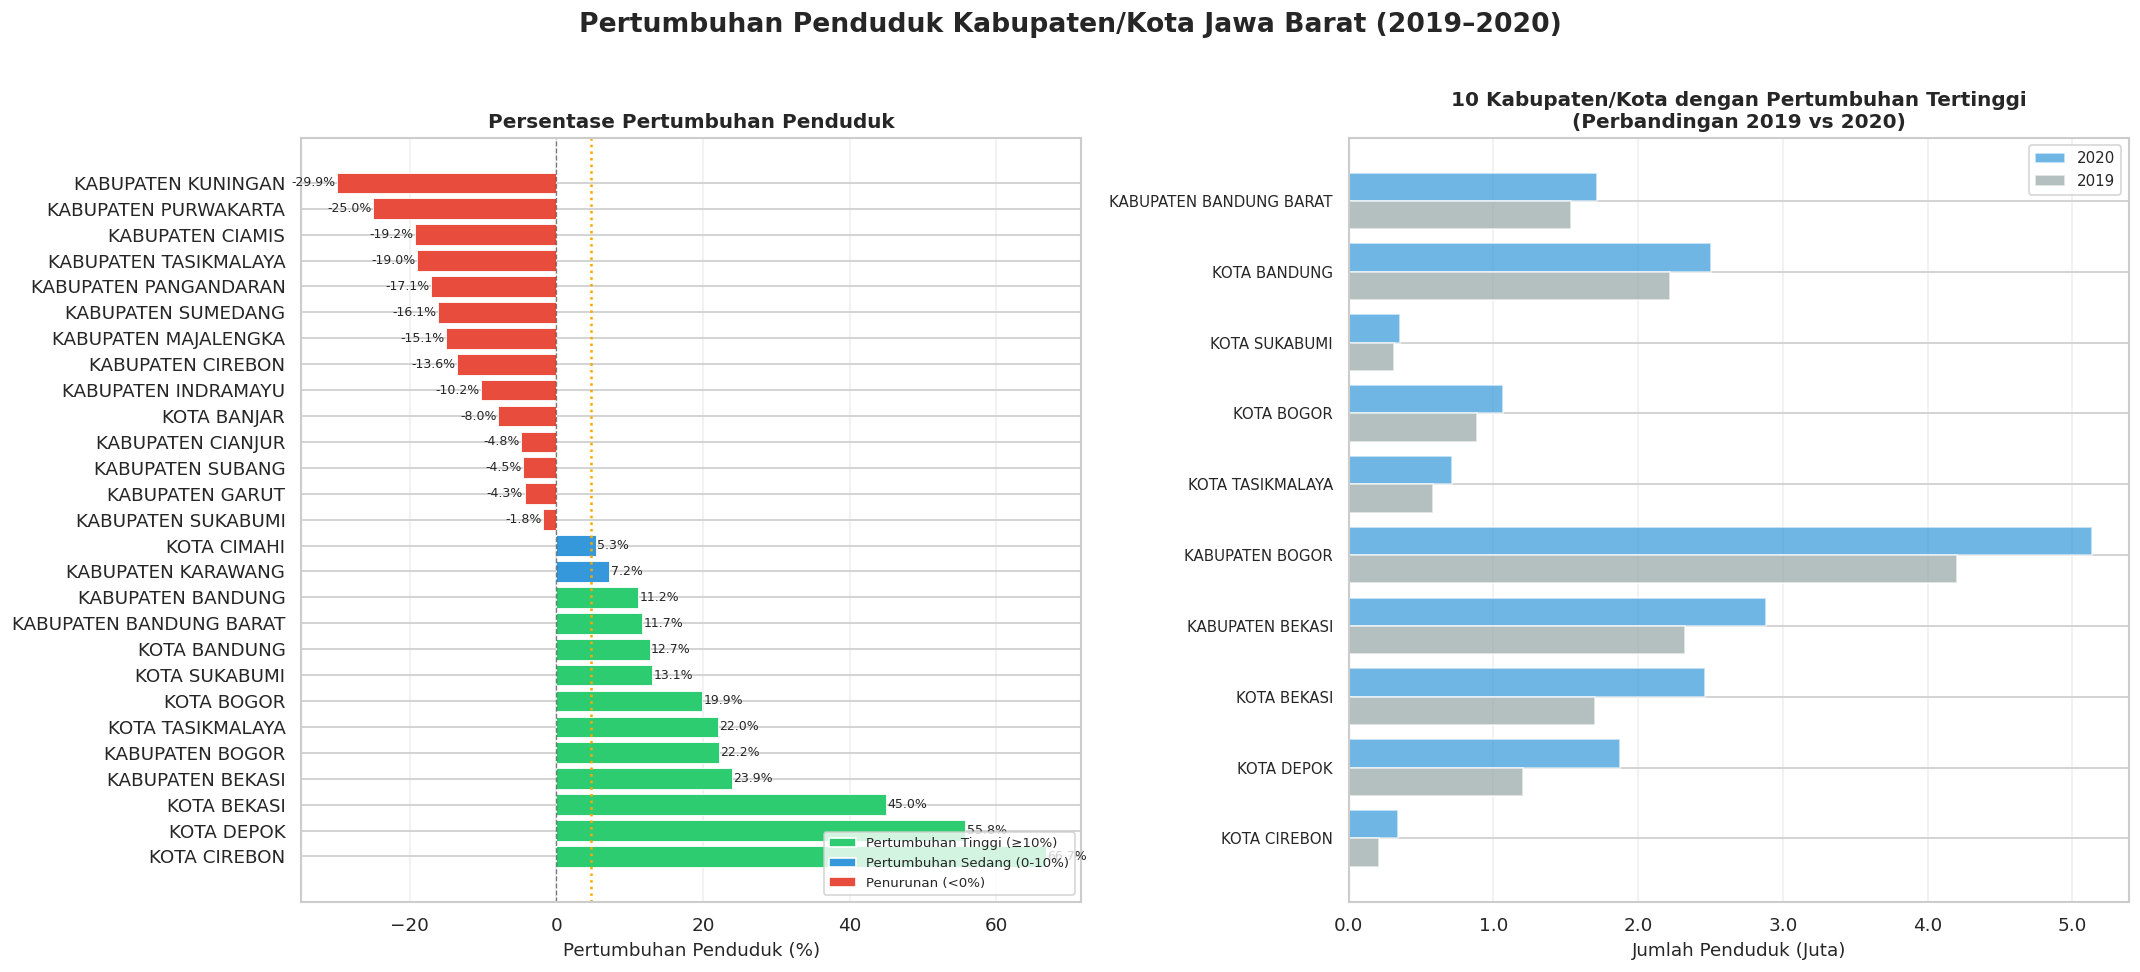

Visualisasi 1 disimpan.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Pertumbuhan Penduduk Kabupaten/Kota Jawa Barat (2019–2020)',
             fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Bar chart pertumbuhan persen
ax1 = axes[0]
sorted_data = pop_pivot_sorted.reset_index(drop=True)
colors = ['#e74c3c' if x < 0 else '#2ecc71' if x >= 10 else '#3498db' for x in sorted_data['pertumbuhan_persen']]

bars = ax1.barh(sorted_data['kabupaten_kota'], sorted_data['pertumbuhan_persen'],
                color=colors, edgecolor='white', linewidth=0.5)
ax1.axvline(x=0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax1.axvline(x=sorted_data['pertumbuhan_persen'].mean(), color='orange',
            linewidth=1.5, linestyle=':', label=f'Rata-rata ({sorted_data["pertumbuhan_persen"].mean():.1f}%)')

for bar, val in zip(bars, sorted_data['pertumbuhan_persen']):
    ax1.text(val + 0.2 if val >= 0 else val - 0.2, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', ha='left' if val >= 0 else 'right', fontsize=7.5)

ax1.set_xlabel('Pertumbuhan Penduduk (%)', fontsize=11)
ax1.set_title('Persentase Pertumbuhan Penduduk', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='x', alpha=0.3)

# Tambah legend warna
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Pertumbuhan Tinggi (≥10%)'),
                   Patch(facecolor='#3498db', label='Pertumbuhan Sedang (0-10%)'),
                   Patch(facecolor='#e74c3c', label='Penurunan (<0%)')]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=8)

# Plot 2: Populasi 2019 vs 2020 (dot plot)
ax2 = axes[1]
top10 = pop_pivot_sorted.head(10)
y_pos = range(len(top10))

ax2.barh(list(y_pos), top10['pop_2020']/1e6, color='#3498db', alpha=0.7,
         label='2020', height=0.4)
ax2.barh([y - 0.4 for y in y_pos], top10['pop_2019']/1e6, color='#95a5a6', alpha=0.7,
         label='2019', height=0.4)

ax2.set_yticks([y - 0.2 for y in y_pos])
ax2.set_yticklabels(top10['kabupaten_kota'], fontsize=9)
ax2.set_xlabel('Jumlah Penduduk (Juta)', fontsize=11)
ax2.set_title('10 Kabupaten/Kota dengan Pertumbuhan Tertinggi\n(Perbandingan 2019 vs 2020)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))

plt.tight_layout()
plt.savefig('dashboard/viz_pertumbuhan.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 1 disimpan.')

### Visualisasi 2: Distribusi Sex Ratio per Kabupaten/Kota (2020)

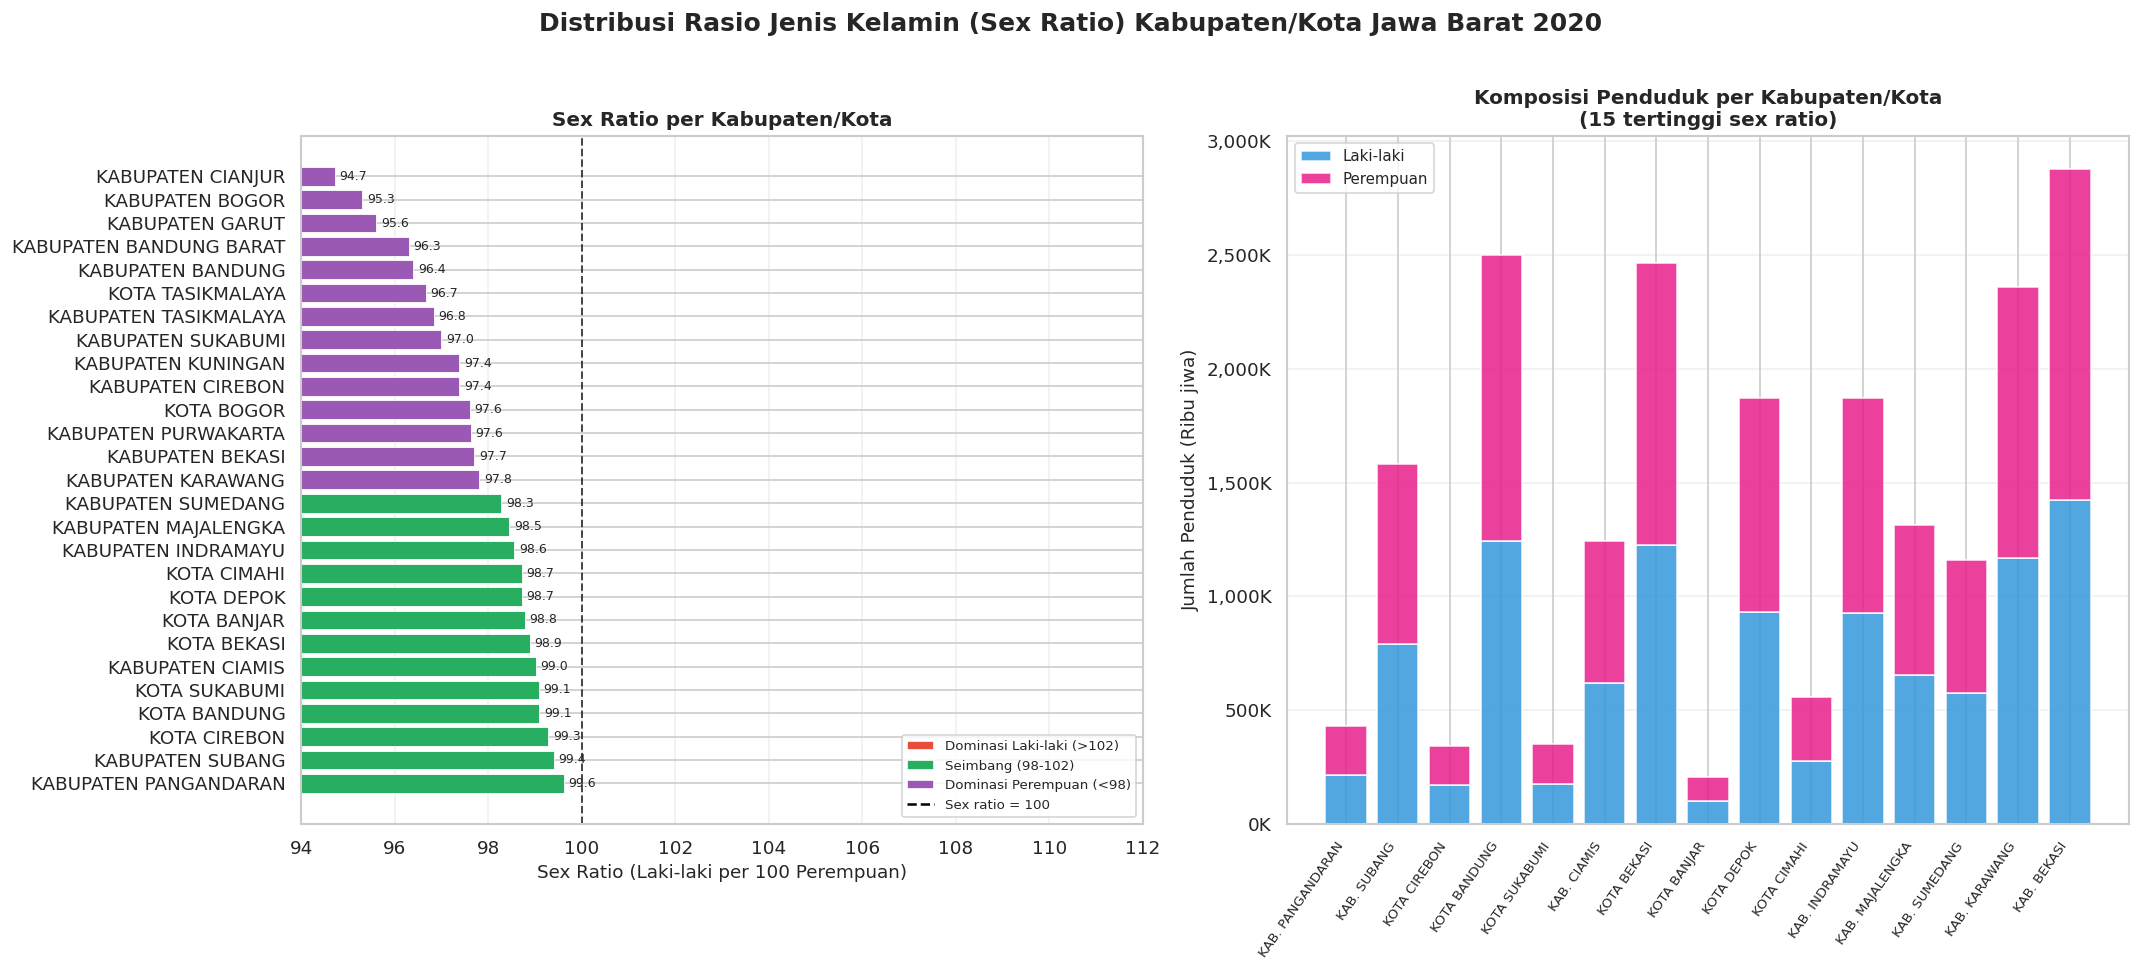

Visualisasi 2 disimpan.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Distribusi Rasio Jenis Kelamin (Sex Ratio) Kabupaten/Kota Jawa Barat 2020',
             fontsize=15, fontweight='bold', y=1.01)

# Plot 1: Bar chart sex ratio
ax1 = axes[0]
sex_sorted = sex_pivot_sorted.reset_index(drop=True)
bar_colors = ['#e74c3c' if x > 102 else '#9b59b6' if x < 98 else '#27ae60' for x in sex_sorted['sex_ratio']]

bars = ax1.barh(sex_sorted['kabupaten_kota'], sex_sorted['sex_ratio'],
                color=bar_colors, edgecolor='white', linewidth=0.5)
ax1.axvline(x=100, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label='Sex ratio = 100 (Seimbang)')

for bar, val in zip(bars, sex_sorted['sex_ratio']):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', ha='left', fontsize=7.5)

ax1.set_xlabel('Sex Ratio (Laki-laki per 100 Perempuan)', fontsize=11)
ax1.set_title('Sex Ratio per Kabupaten/Kota', fontsize=12, fontweight='bold')
ax1.set_xlim(94, 112)

from matplotlib.patches import Patch
leg_els = [Patch(facecolor='#e74c3c', label='Dominasi Laki-laki (>102)'),
           Patch(facecolor='#27ae60', label='Seimbang (98-102)'),
           Patch(facecolor='#9b59b6', label='Dominasi Perempuan (<98)'),
           plt.Line2D([0],[0], color='black', linestyle='--', label='Sex ratio = 100')]
ax1.legend(handles=leg_els, fontsize=8, loc='lower right')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Stacked bar komposisi jenis kelamin
ax2 = axes[1]
sex_top = sex_sorted.head(15)
x = range(len(sex_top))

p1 = ax2.bar(x, sex_top['laki_laki']/1000, color='#3498db', label='Laki-laki', alpha=0.85)
p2 = ax2.bar(x, sex_top['perempuan']/1000, bottom=sex_top['laki_laki']/1000,
             color='#e91e8c', label='Perempuan', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels([n.replace('KABUPATEN ','KAB. ').replace('KOTA ','KOTA ') for n in sex_top['kabupaten_kota']],
                    rotation=55, ha='right', fontsize=8)
ax2.set_ylabel('Jumlah Penduduk (Ribu jiwa)', fontsize=11)
ax2.set_title('Komposisi Penduduk per Kabupaten/Kota\n(15 tertinggi sex ratio)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}K'))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dashboard/viz_sexratio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 2 disimpan.')

### Visualisasi 3: Analisis Clustering Kabupaten/Kota

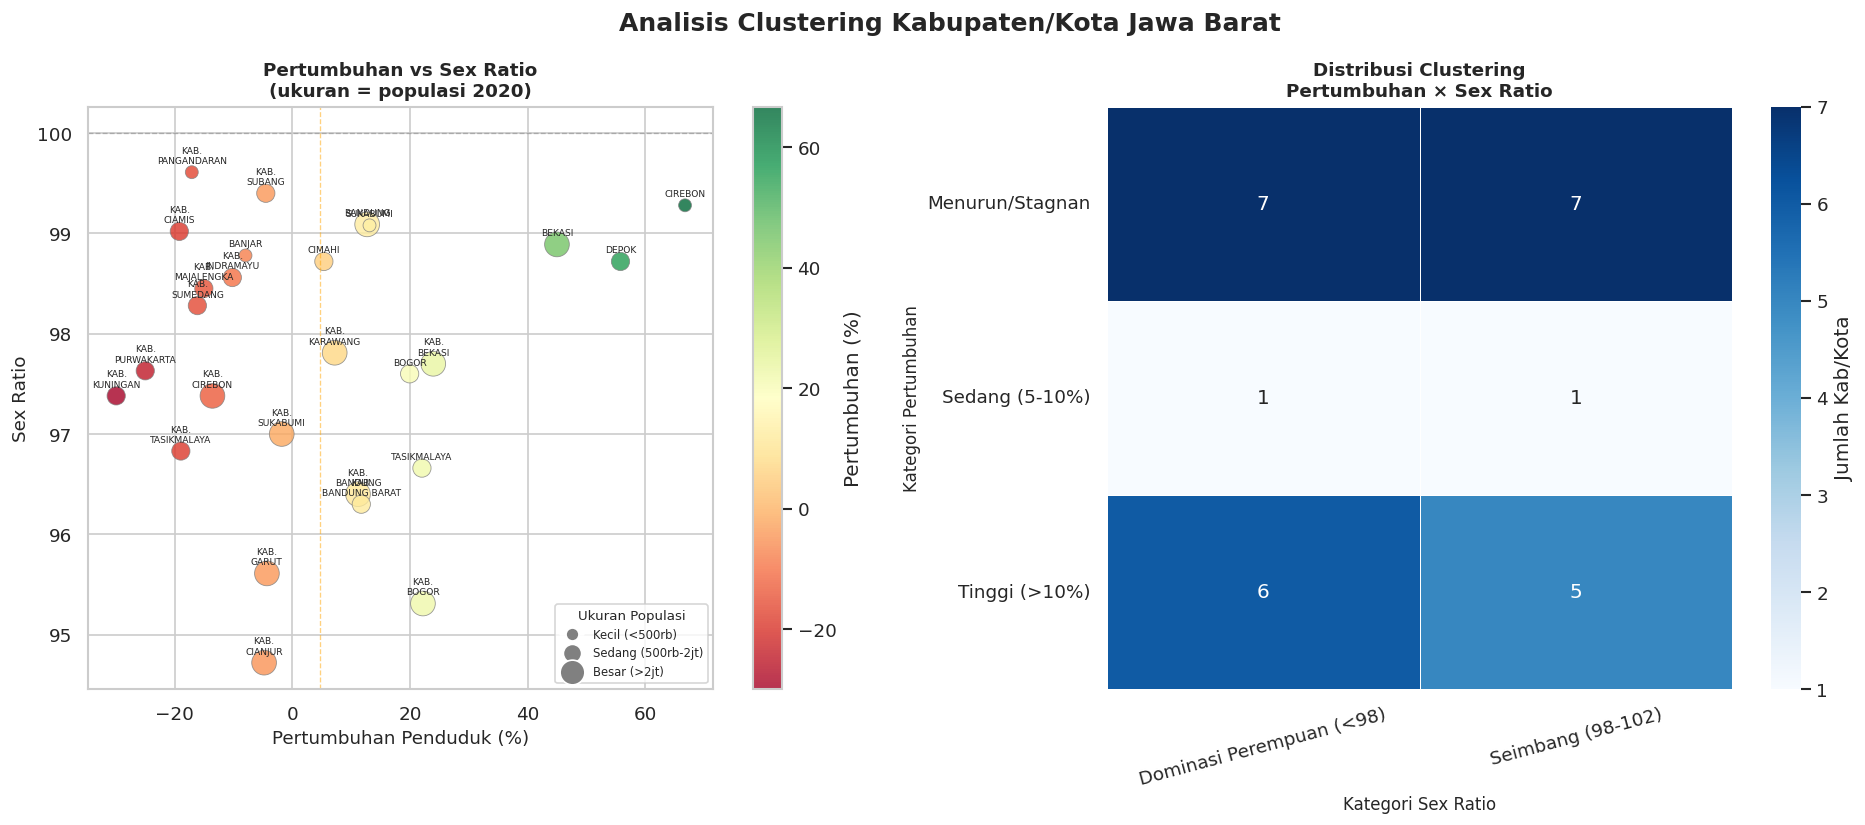

Visualisasi 3 disimpan.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analisis Clustering Kabupaten/Kota Jawa Barat', fontsize=15, fontweight='bold')

# Plot 1: Scatter — Pertumbuhan vs Sex Ratio
ax1 = axes[0]
cluster_data = analisis_gabung.copy()
size_map = {'Kecil (<500rb)': 60, 'Sedang (500rb-2jt)': 120, 'Besar (>2jt)': 220}
sizes = cluster_data['kategori_ukuran'].map(size_map)

scatter = ax1.scatter(
    cluster_data['pertumbuhan_persen'],
    cluster_data['sex_ratio'],
    s=sizes,
    c=cluster_data['pertumbuhan_persen'],
    cmap='RdYlGn',
    alpha=0.8,
    edgecolors='gray',
    linewidths=0.5
)

for _, row in cluster_data.iterrows():
    label = row['kabupaten_kota'].replace('KABUPATEN ','KAB.\n').replace('KOTA ','')
    ax1.annotate(label, (row['pertumbuhan_persen'], row['sex_ratio']),
                fontsize=5.5, ha='center', va='bottom',
                xytext=(0, 4), textcoords='offset points')

ax1.axhline(y=100, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
ax1.axvline(x=cluster_data['pertumbuhan_persen'].mean(), color='orange',
            linestyle='--', alpha=0.5, linewidth=0.8)

plt.colorbar(scatter, ax=ax1, label='Pertumbuhan (%)')
ax1.set_xlabel('Pertumbuhan Penduduk (%)', fontsize=11)
ax1.set_ylabel('Sex Ratio', fontsize=11)
ax1.set_title('Pertumbuhan vs Sex Ratio\n(ukuran = populasi 2020)', fontsize=11, fontweight='bold')

from matplotlib.lines import Line2D
leg_items = [Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
             markersize=s**0.5, label=l) for l, s in size_map.items()]
ax1.legend(handles=leg_items, title='Ukuran Populasi', fontsize=7, title_fontsize=8)

# Plot 2: Treemap-style (heatmap) proporsi
ax2 = axes[1]
pivot_cat = pd.crosstab(cluster_data['kategori_pertumbuhan'], cluster_data['kategori_sex_ratio'])
sns.heatmap(pivot_cat, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=ax2, cbar_kws={'label': 'Jumlah Kab/Kota'})
ax2.set_title('Distribusi Clustering\nPertumbuhan × Sex Ratio', fontsize=11, fontweight='bold')
ax2.set_xlabel('Kategori Sex Ratio', fontsize=10)
ax2.set_ylabel('Kategori Pertumbuhan', fontsize=10)
ax2.tick_params(axis='x', rotation=15)
ax2.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('dashboard/viz_clustering.png', dpi=150, bbox_inches='tight')
plt.show()
print('Visualisasi 3 disimpan.')

## 5. Conclusion & Recommendation

### Kesimpulan 1: Pertumbuhan Penduduk (Menjawab Pertanyaan 1)

Terdapat **ketimpangan pertumbuhan penduduk yang signifikan** antar kabupaten/kota di Jawa Barat periode 2019–2020:

- **Kabupaten/kota dengan pertumbuhan tertinggi** umumnya adalah wilayah pinggiran kota industri dan penyangga (hinterland) seperti Kabupaten Karawang, Bekasi, dan Purwakarta — mengindikasikan daya tarik lapangan kerja di kawasan industri.
- **Kota-kota besar seperti Bandung dan Cirebon** justru mengalami pertumbuhan lebih rendah atau bahkan stagnan, mengindikasikan fenomena *suburbanisasi* — penduduk bergerak dari inti kota ke kabupaten di sekitarnya.
- Secara keseluruhan, total penduduk Jawa Barat tumbuh positif dari 2019 ke 2020, menunjukkan dinamika kependudukan yang aktif.

### Kesimpulan 2: Rasio Jenis Kelamin (Menjawab Pertanyaan 2)

**Sex ratio Jawa Barat secara keseluruhan mendekati seimbang**, namun terdapat variasi yang mencerminkan pola sosial-ekonomi:

- **Kabupaten dengan dominasi laki-laki (sex ratio >102)** cenderung merupakan kawasan industri/perkebunan yang menarik migrasi tenaga kerja laki-laki (misalnya Karawang, Bekasi, Purwakarta).
- **Kota dengan sex ratio lebih rendah** umumnya adalah pusat pendidikan dan jasa yang lebih seimbang atau sedikit dominasi perempuan, karena sektor informal dan kesempatan pendidikan menarik migrasi perempuan.
- Tidak ada kabupaten/kota yang memiliki ketidakseimbangan gender yang ekstrem (semua masih dalam rentang wajar).

---

### Rekomendasi Action Item

Berdasarkan kedua kesimpulan di atas, berikut rekomendasi strategis:

1. **Prioritaskan investasi infrastruktur** (perumahan, transportasi, layanan kesehatan, sekolah) di kabupaten dengan pertumbuhan penduduk tertinggi untuk mengantisipasi tekanan permintaan layanan publik.

2. **Rancang program pemberdayaan berbasis gender** di kabupaten dengan sex ratio tinggi (dominasi laki-laki), khususnya terkait perlindungan pekerja migran, layanan kesehatan reproduksi, dan pemberdayaan perempuan di sektor industri.

3. **Evaluasi kebijakan tata kota** di kota-kota yang mengalami penurunan penduduk untuk memahami penyebab suburbanisasi — apakah karena faktor biaya hidup, hunian, atau ketersediaan lapangan kerja — dan susun program revitalisasi pusat kota.

4. **Bangun sistem pemantauan kependudukan berbasis data** yang diperbarui setidaknya tahunan di seluruh 27 kabupaten/kota Jawa Barat untuk mendukung pengambilan keputusan yang lebih responsif dan berbasis bukti (*evidence-based policy*).